Dataset Shape: (900, 2)
                                              Review  Liked
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1

Sample Cleaned Review: wow love place

=== Bag of Words Results ===


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!



Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.61      0.68        82
           1       0.72      0.85      0.78        98

    accuracy                           0.74       180
   macro avg       0.75      0.73      0.73       180
weighted avg       0.74      0.74      0.73       180



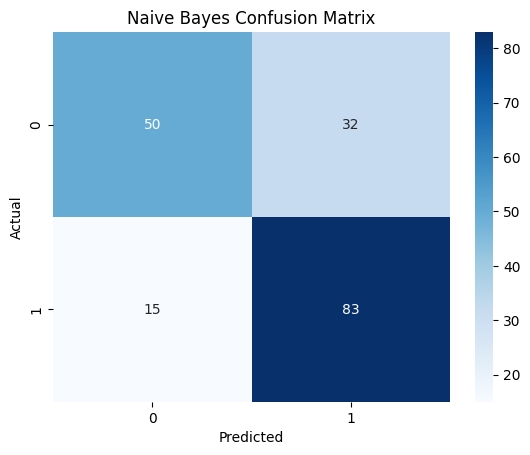


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.71      0.73        82
           1       0.77      0.82      0.79        98

    accuracy                           0.77       180
   macro avg       0.77      0.76      0.76       180
weighted avg       0.77      0.77      0.77       180



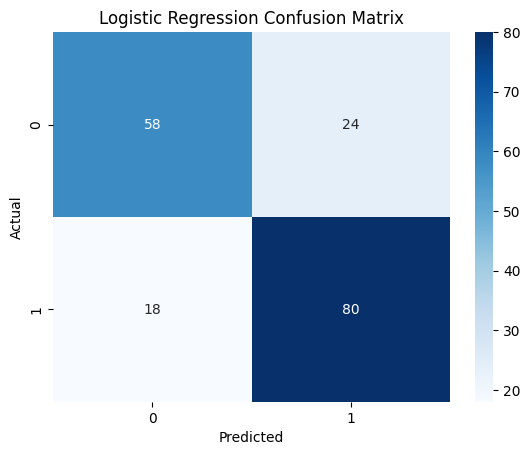


SVM Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.68      0.72        82
           1       0.76      0.83      0.79        98

    accuracy                           0.76       180
   macro avg       0.76      0.75      0.76       180
weighted avg       0.76      0.76      0.76       180



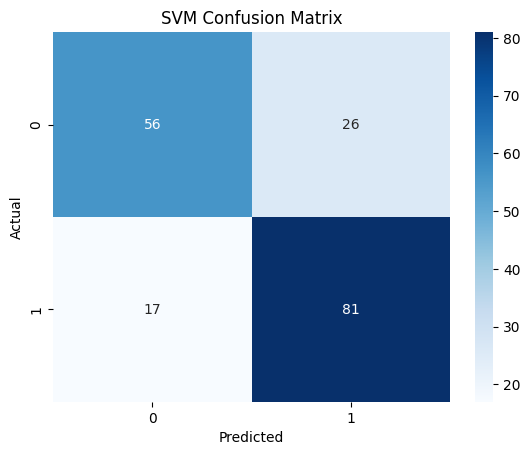


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.79      0.76        82
           1       0.81      0.74      0.78        98

    accuracy                           0.77       180
   macro avg       0.77      0.77      0.77       180
weighted avg       0.77      0.77      0.77       180



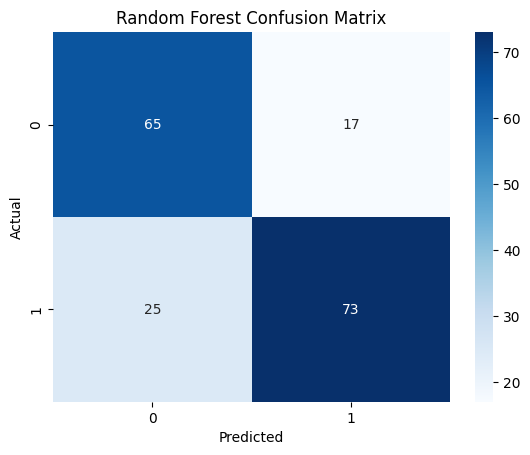

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:29:31] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.78      0.72        82
           1       0.79      0.68      0.73        98

    accuracy                           0.73       180
   macro avg       0.73      0.73      0.73       180
weighted avg       0.74      0.73      0.73       180



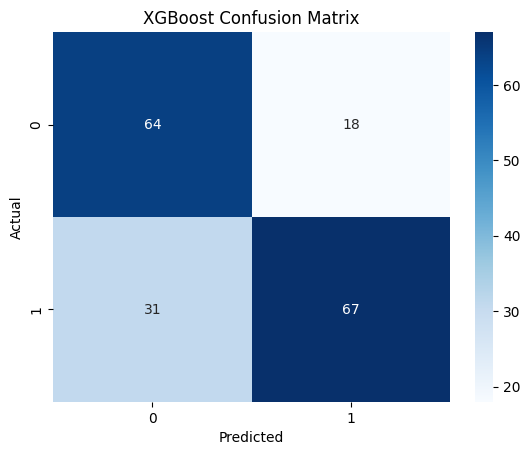

                     Accuracy  Precision  Recall  F1 Score
Naive Bayes             0.739      0.722   0.847     0.779
Logistic Regression     0.767      0.769   0.816     0.792
SVM                     0.761      0.757   0.827     0.790
Random Forest           0.767      0.811   0.745     0.777
XGBoost                 0.728      0.788   0.684     0.732

=== TF-IDF Results ===

Naive Bayes Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.60      0.61        82
           1       0.68      0.70      0.69        98

    accuracy                           0.66       180
   macro avg       0.65      0.65      0.65       180
weighted avg       0.65      0.66      0.65       180



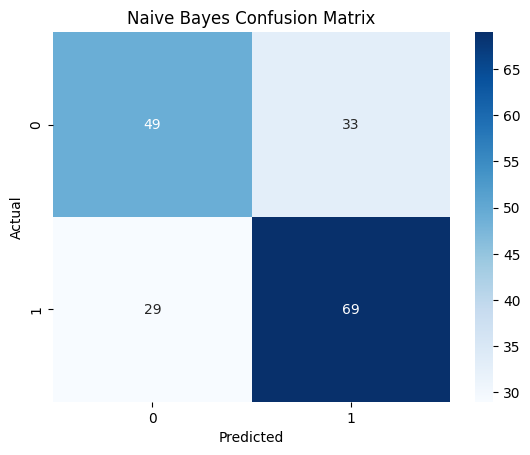


Logistic Regression Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.72      0.75        82
           1       0.78      0.83      0.80        98

    accuracy                           0.78       180
   macro avg       0.78      0.77      0.77       180
weighted avg       0.78      0.78      0.78       180



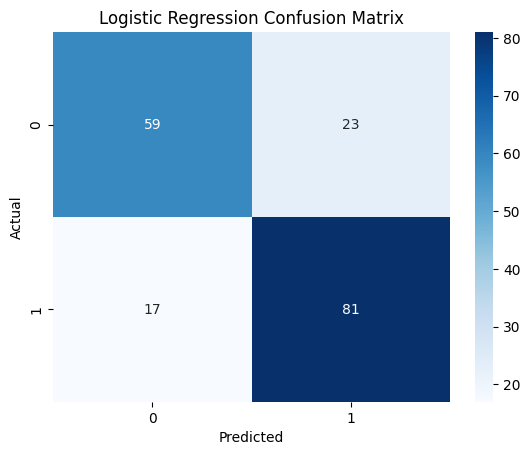


SVM Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.72      0.74        82
           1       0.78      0.82      0.80        98

    accuracy                           0.77       180
   macro avg       0.77      0.77      0.77       180
weighted avg       0.77      0.77      0.77       180



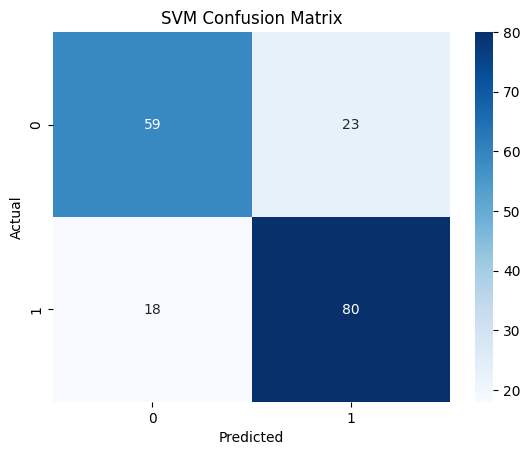


Random Forest Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.85      0.78        82
           1       0.85      0.71      0.78        98

    accuracy                           0.78       180
   macro avg       0.78      0.78      0.78       180
weighted avg       0.79      0.78      0.78       180



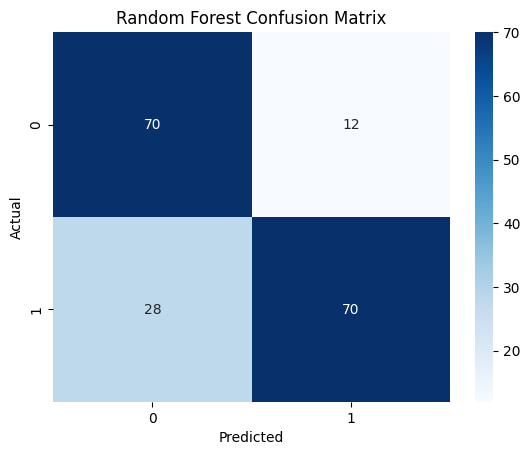

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [07:29:34] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.82      0.72        82
           1       0.81      0.63      0.71        98

    accuracy                           0.72       180
   macro avg       0.73      0.72      0.72       180
weighted avg       0.73      0.72      0.72       180



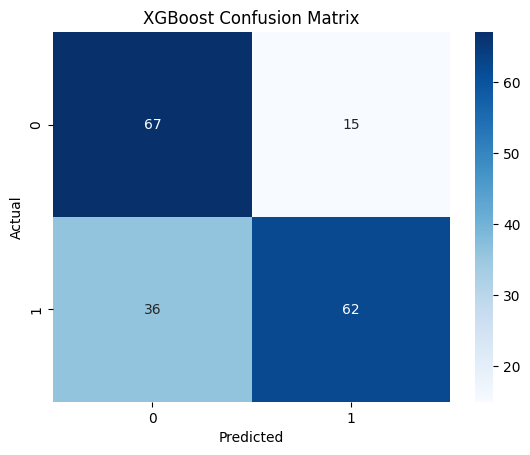

                     Accuracy  Precision  Recall  F1 Score
Naive Bayes             0.656      0.676   0.704     0.690
Logistic Regression     0.778      0.779   0.827     0.802
SVM                     0.772      0.777   0.816     0.796
Random Forest           0.778      0.854   0.714     0.778
XGBoost                 0.717      0.805   0.633     0.709


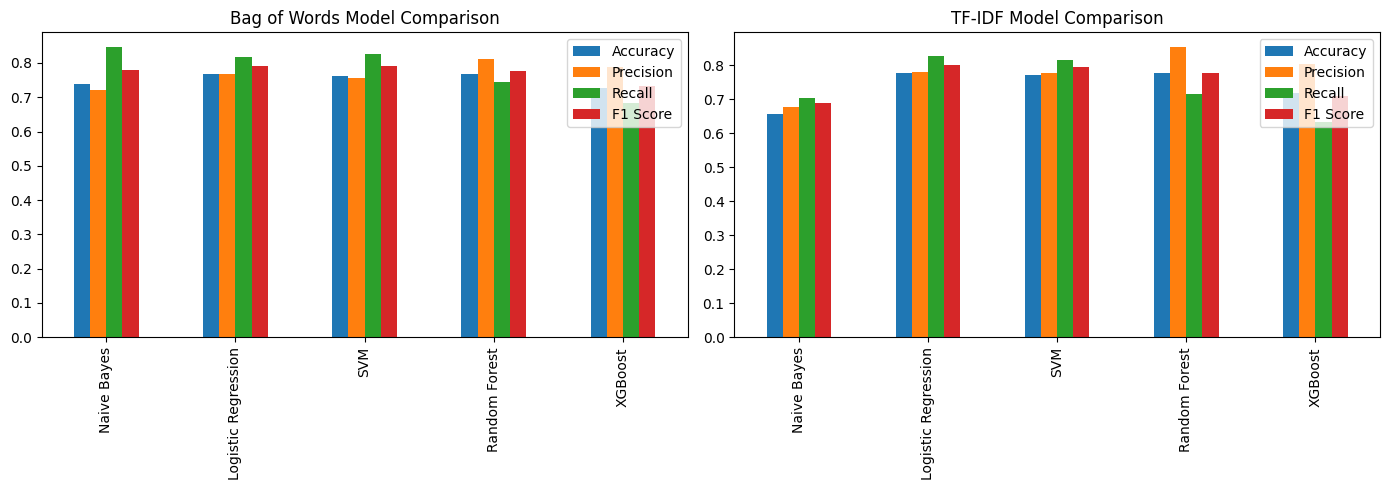

In [ ]:
# ============================================================
# SENTIMENT ANALYSIS OF RESTAURANT REVIEWS - RESEARCH VERSION
# ============================================================

# 1️⃣ Import Libraries
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 2️⃣ Load Dataset
df = pd.read_csv('a1_RestaurantReviews_HistoricDump.tsv', sep='\t')
print("Dataset Shape:", df.shape)
print(df.head())

# 3️⃣ Text Preprocessing
nltk.download('stopwords')
ps = PorterStemmer()
all_stopwords = stopwords.words('english')
all_stopwords.remove('not')

corpus = []
for review in df['Review']:
    review = re.sub('[^a-zA-Z]', ' ', review)
    review = review.lower()
    review = review.split()
    review = [ps.stem(word) for word in review if word not in set(all_stopwords)]
    review = ' '.join(review)
    corpus.append(review)

print("\nSample Cleaned Review:", corpus[0])

# 4️⃣ Feature Extraction: BoW & TF-IDF
cv = CountVectorizer(max_features=1500)
X_bow = cv.fit_transform(corpus).toarray()

tfidf = TfidfVectorizer(max_features=1500)
X_tfidf = tfidf.fit_transform(corpus).toarray()

y = df['Liked'].values

# 5️⃣ Train-Test Split
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# 6️⃣ Define Models
models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

# 7️⃣ Evaluation Function
def evaluate_models(X_train, X_test, y_train, y_test):
    results = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results[name] = {
            "Accuracy": round(accuracy_score(y_test, y_pred), 3),
            "Precision": round(precision_score(y_test, y_pred), 3),
            "Recall": round(recall_score(y_test, y_pred), 3),
            "F1 Score": round(f1_score(y_test, y_pred), 3)
        }
        print(f"\n{name} Classification Report:\n", classification_report(y_test, y_pred))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
        plt.title(f'{name} Confusion Matrix')
        plt.xlabel('Predicted')
        plt.ylabel('Actual')
        plt.show()
    return pd.DataFrame(results).T

# 8️⃣ Train and Evaluate for BoW
print("\n=== Bag of Words Results ===")
bow_results = evaluate_models(X_train_bow, X_test_bow, y_train, y_test)
print(bow_results)

# 9️⃣ Train and Evaluate for TF-IDF
print("\n=== TF-IDF Results ===")
tfidf_results = evaluate_models(X_train_tfidf, X_test_tfidf, y_train, y_test)
print(tfidf_results)

# 🔟 Visual Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
bow_results.plot(kind='bar', ax=axes[0], title='Bag of Words Model Comparison')
tfidf_results.plot(kind='bar', ax=axes[1], title='TF-IDF Model Comparison')
plt.tight_layout()
plt.show()

# ✅ End of Research Code
